# CMPE492 Phase 3 — Hybrid Puppet & Painter Pipeline (Final)

**Architecture:** MimicTalk (audio → landmarks) + AniPortrait Lmk2Video (landmarks → photorealistic frames)

**Config:** DDIM scheduler, CFG 3.5, 25 steps, selective landmark smoothing

---
**Run:** 1A → 1B → 2 → 3 → 4 → 5 → 6 → 7a → 7b → 7c → 8 → 9 → 10 → 11

## Cell 1A — MediaPipe

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1A — Install & Patch MediaPipe  (run FIRST)
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, sys, re

gpu = subprocess.run(
    'nvidia-smi --query-gpu=name,memory.total --format=csv,noheader',
    shell=True, capture_output=True, text=True
).stdout.strip()
print('GPU:', gpu)

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'mediapipe==0.10.14', '--no-cache-dir'], check=True)
print('mediapipe installed')

subprocess.run(
    'find /usr/local/lib/python3.12/dist-packages/mediapipe '
    '-name "*.pyc" -delete', shell=True)

py_init = '/usr/local/lib/python3.12/dist-packages/mediapipe/python/__init__.py'
patched_py = (
    '"""MediaPipe Python API — patched for Colab 3.12."""\n'
    'import sys as _sys\n'
    'from mediapipe.python import _framework_bindings as _fb\n\n'
    'for _attr in [\n'
    '    "calculator_graph", "image", "image_frame", "matrix", "packet",\n'
    '    "timestamp", "validated_graph_config", "model_ckpt_util", "resource_util",\n'
    ']:\n'
    '    _sys.modules[f"mediapipe.python._framework_bindings.{_attr}"] = _fb\n\n'
    'import mediapipe.python.packet_creator\n'
    'import mediapipe.python.packet_getter\n'
)
with open(py_init, 'w') as f:
    f.write(patched_py)
print('Patched mediapipe/python/__init__.py')

top_init = '/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py'
with open(top_init) as f:
    src = f.read()
src = re.sub(
    r'^(import mediapipe\.\S+ as \S+)$',
    r'try:\n    \1\nexcept Exception:\n    pass',
    src, flags=re.MULTILINE)
src = re.sub(
    r'^(import mediapipe\.\S+\.\S+ as \S+)$',
    r'try:\n    \1\nexcept Exception:\n    pass',
    src, flags=re.MULTILINE)
src = re.sub(
    r'^(del \w+)$',
    r'try:\n    \1\nexcept NameError:\n    pass',
    src, flags=re.MULTILINE)
with open(top_init, 'w') as f:
    f.write(src)
print('Patched mediapipe/__init__.py')

for key in list(sys.modules.keys()):
    if 'mediapipe' in key:
        del sys.modules[key]

import mediapipe as mp
print(f'mediapipe {mp.__version__}')
import mediapipe.python.solutions.drawing_utils as drawing_utils
import mediapipe.python.solutions.face_mesh as face_mesh
print(f'FACEMESH_TESSELATION: {len(face_mesh.FACEMESH_TESSELATION)} connections')
print('\n✅ Cell 1A complete')


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition, 97887 MiB
mediapipe installed
Patched mediapipe/python/__init__.py
Patched mediapipe/__init__.py
mediapipe 0.10.14
FACEMESH_TESSELATION: 2556 connections

✅ Cell 1A complete


## Cell 1B — Pip Dependencies

In [ ]:
import subprocess, sys

pkgs = [
    'diffusers==0.27.2', 'transformers==4.36.2', 'accelerate==0.25.0',
    'peft==0.7.1', 'omegaconf', 'einops', 'av', 'ffmpeg-python', 'xformers',
]
for pkg in pkgs:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       capture_output=True, text=True)
    print(f'  {"✅" if r.returncode == 0 else "⚠"} {pkg}')

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'huggingface_hub==0.23.4', '--force-reinstall', '--no-deps'], check=True)
print('  ✅ huggingface_hub==0.23.4')

import huggingface_hub
if not hasattr(huggingface_hub, 'cached_download'):
    huggingface_hub.cached_download = huggingface_hub.hf_hub_download

import torch
print(f'\n  PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')
import mediapipe as mp
assert mp.__version__ == '0.10.14'
print(f'  mediapipe: {mp.__version__} (intact)')
import diffusers, transformers
print(f'  diffusers: {diffusers.__version__}, transformers: {transformers.__version__}')
print('\n✅ Cell 1B complete')


  ✅ diffusers==0.27.2
  ✅ transformers==4.36.2
  ✅ accelerate==0.25.0
  ✅ peft==0.7.1
  ✅ omegaconf
  ✅ einops
  ✅ av
  ✅ ffmpeg-python
  ✅ xformers
  ✅ huggingface_hub==0.23.4


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.



  PyTorch: 2.10.0+cu128, CUDA: True
  mediapipe: 0.10.14 (intact)


0it [00:00, ?it/s]

  diffusers: 0.27.2, transformers: 4.36.2

✅ Cell 1B complete


## Cell 2 — Clone AniPortrait

In [ ]:
import os, sys, subprocess
REPO_DIR = '/content/AniPortrait'
if not os.path.exists(REPO_DIR):
    subprocess.run('git clone https://github.com/Zejun-Yang/AniPortrait.git /content/AniPortrait',
                   shell=True, check=True)
    print('✅ Cloned AniPortrait')
else:
    print('✅ AniPortrait already present')
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print('CWD:', os.getcwd())


✅ Cloned AniPortrait
CWD: /content/AniPortrait


## Cell 3 — Download Weights

In [ ]:
import os, urllib.request
from huggingface_hub import snapshot_download, hf_hub_download
os.makedirs('pretrained_weights', exist_ok=True)

downloads = [
    ('SD v1.5', 'runwayml/stable-diffusion-v1-5', 'pretrained_weights/stable-diffusion-v1-5',
     {'ignore_patterns': ['*.ckpt', '*.safetensors', 'safety_checker/*']}),
    ('VAE', 'stabilityai/sd-vae-ft-mse', 'pretrained_weights/sd-vae-ft-mse', {}),
    ('CLIP ViT-L', 'openai/clip-vit-large-patch14', 'pretrained_weights/image_encoder',
     {'ignore_patterns': ['*.msgpack', '*.h5', 'flax_model*', 'tf_model*']}),
]
for name, repo, path, kwargs in downloads:
    if not os.path.exists(path):
        print(f'Downloading {name}...')
        snapshot_download(repo_id=repo, local_dir=path, **kwargs)
    print(f'  ✅ {name}')

for fname in ['denoising_unet.pth', 'reference_unet.pth', 'pose_guider.pth', 'motion_module.pth']:
    dst = f'pretrained_weights/{fname}'
    if not os.path.exists(dst):
        print(f'Downloading {fname}...')
        hf_hub_download(repo_id='ZJYang/AniPortrait', filename=fname, local_dir='pretrained_weights')
    print(f'  ✅ {fname} ({os.path.getsize(dst)//(1024*1024)} MB)')

os.makedirs('src/utils/mp_models', exist_ok=True)
for fname, url in [
    ('face_landmarker_v2_with_blendshapes.task',
     'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'),
    ('blaze_face_short_range.tflite',
     'https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite'),
]:
    dst = f'src/utils/mp_models/{fname}'
    if not os.path.exists(dst):
        urllib.request.urlretrieve(url, dst)
    print(f'  ✅ {fname}')
print('\n✅ All weights ready')


Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/492M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

  ✅ reference_unet.pth (3279 MB)


pose_guider.pth:   0%|          | 0.00/670M [00:00<?, ?B/s]

  ✅ pose_guider.pth (639 MB)


motion_module.pth:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

  ✅ motion_module.pth (1733 MB)
  ✅ face_landmarker_v2_with_blendshapes.task
  ✅ blaze_face_short_range.tflite

✅ All weights ready


## Cell 4 — Write Configs

In [ ]:
import os
os.chdir('/content/AniPortrait')
os.makedirs('configs/prompts', exist_ok=True)

config_yaml = (
    'pretrained_base_model_path: "./pretrained_weights/stable-diffusion-v1-5"\n'
    'pretrained_vae_path: "./pretrained_weights/sd-vae-ft-mse"\n'
    'image_encoder_path: "./pretrained_weights/image_encoder"\n\n'
    'denoising_unet_path: "./pretrained_weights/denoising_unet.pth"\n'
    'reference_unet_path: "./pretrained_weights/reference_unet.pth"\n'
    'pose_guider_path: "./pretrained_weights/pose_guider.pth"\n'
    'motion_module_path: "./pretrained_weights/motion_module.pth"\n\n'
    'inference_config: "./configs/inference/inference_v2.yaml"\n'
    'weight_dtype: "fp16"\n'
)
with open('configs/prompts/phase3_hybrid.yaml', 'w') as f:
    f.write(config_yaml)
print('✅ Config written (inference_v2.yaml / Zero-SNR / v_prediction)')


✅ Config written (inference_v2.yaml / Zero-SNR / v_prediction)


## Cell 5 — Upload Artifacts

In [ ]:
from google.colab import files
import os, glob, cv2

os.makedirs('/content/phase3_inputs', exist_ok=True)
print('Upload: landmarks .npy + reference image + audio (.wav/.mp3)')
uploaded = files.upload()
for fname, data in uploaded.items():
    dst = f'/content/phase3_inputs/{fname}'
    with open(dst, 'wb') as f: f.write(data)
    print(f'  Saved: {dst}  ({len(data)//1024} KB)')

npy_files   = glob.glob('/content/phase3_inputs/*.npy')
img_files   = glob.glob('/content/phase3_inputs/*.png') + glob.glob('/content/phase3_inputs/*.jpg') + glob.glob('/content/phase3_inputs/*.jpeg')
audio_files = glob.glob('/content/phase3_inputs/*.wav') + glob.glob('/content/phase3_inputs/*.mp3')

landmark_npy_path = npy_files[0]   if npy_files   else None
ref_image_path    = img_files[0]   if img_files   else None
audio_path        = audio_files[0] if audio_files else None

print('landmarks :', landmark_npy_path or '❌')
print('ref image :', ref_image_path    or '❌')
print('audio     :', audio_path        or '(silent)')

if not landmark_npy_path: raise FileNotFoundError('landmarks .npy not found')
if not ref_image_path:    raise FileNotFoundError('reference image not found')

img = cv2.imread(ref_image_path)
img_512 = cv2.resize(img, (512, 512))
ref_image_path_512 = '/content/phase3_inputs/ref_frame_512.png'
cv2.imwrite(ref_image_path_512, img_512)
print(f'✅ Reference image → 512x512')


Upload: landmarks .npy + reference image + audio (.wav/.mp3)


Saving refff.png to refff.png
Saving myTrainingShorted_clip_zoomed_shifted_landmarks (1).npy to myTrainingShorted_clip_zoomed_shifted_landmarks (1) (1).npy
Saving driven_audio (1).wav to driven_audio (1) (1).wav
  Saved: /content/phase3_inputs/refff.png  (344 KB)
  Saved: /content/phase3_inputs/myTrainingShorted_clip_zoomed_shifted_landmarks (1) (1).npy  (5131 KB)
  Saved: /content/phase3_inputs/driven_audio (1) (1).wav  (589 KB)
landmarks : /content/phase3_inputs/myTrainingShorted_clip_zoomed_shifted_landmarks (1).npy
ref image : /content/phase3_inputs/ref_frame_512.png
audio     : /content/phase3_inputs/driven_audio (1) (1).wav
✅ Reference image → 512x512


## Cell 6 — Bridge (selective smoothing)

Loaded: (916, 478, 3)  (916 frames @ 25fps = 36.6s)
✅ Selective smoothing: 438 smoothed, 40 lip landmarks preserved
Mesh density: 12646/262144 pixels (4.8%)


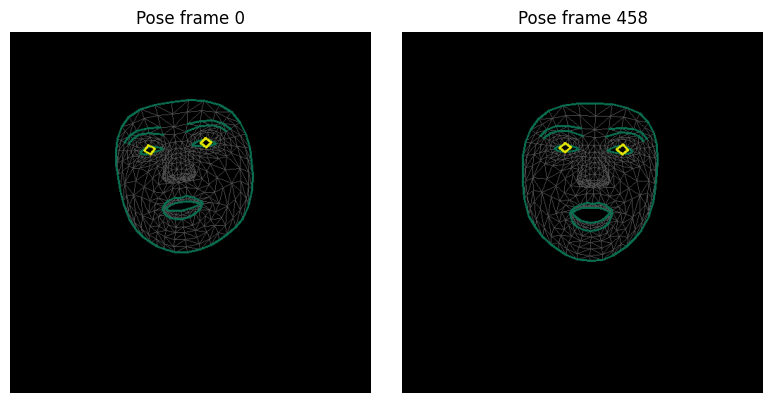

Rendering pose frames: 100%|██████████| 916/916 [00:03<00:00, 235.20it/s]


Rendered: 916 frames, failed: 0

✅ Bridge complete — pose_pil_list ready


In [ ]:
# ── CELL 6: Bridge — MimicTalk landmarks → AniPortrait pose video ─────────────
# Only change from baseline: selective smoothing (smooth non-lip, preserve lip raw)
import os, sys, cv2
import numpy as np
import mediapipe as mp
from mediapipe.framework.formats import landmark_pb2
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm
import matplotlib.pyplot as plt

os.chdir('/content/AniPortrait')
if '/content/AniPortrait' not in sys.path:
    sys.path.insert(0, '/content/AniPortrait')

drawing_utils = mp.solutions.drawing_utils
face_mesh_mp  = mp.solutions.face_mesh

# Standard styles (same as original — DO NOT change, model was trained on these)
TESS_STYLE    = drawing_utils.DrawingSpec(color=(80, 80, 80),  thickness=1)
CONTOUR_STYLE = drawing_utils.DrawingSpec(color=(80, 110, 10), thickness=2)
IRIS_STYLE    = drawing_utils.DrawingSpec(color=(0, 230, 230), thickness=2)

def render_dense_pose(lmks_norm, size=(512, 512)):
    H, W = size
    img = np.zeros((H, W, 3), dtype=np.uint8)
    lm_list = landmark_pb2.NormalizedLandmarkList()
    for x, y, z in lmks_norm:
        lm = lm_list.landmark.add()
        lm.x, lm.y, lm.z = float(x), float(y), float(z)
    drawing_utils.draw_landmarks(img, lm_list, face_mesh_mp.FACEMESH_TESSELATION, None, TESS_STYLE)
    drawing_utils.draw_landmarks(img, lm_list, face_mesh_mp.FACEMESH_CONTOURS, None, CONTOUR_STYLE)
    drawing_utils.draw_landmarks(img, lm_list, face_mesh_mp.FACEMESH_IRISES, None, IRIS_STYLE)
    return img

# Load landmarks
landmarks_np = np.load(landmark_npy_path)
N_frames = landmarks_np.shape[0]
print(f'Loaded: {landmarks_np.shape}  ({N_frames} frames @ 25fps = {N_frames/25:.1f}s)')

# ★ Selective smoothing: smooth head/jaw/eyes, preserve lip landmarks raw
LIP_INDICES = sorted(set([61,146,91,181,84,17,314,405,321,375,291,409,270,269,
     267,0,37,39,40,185,80,81,82,13,312,311,310,415,308,324,318,402,317,14,87,178,88,95,78,191]))
lip_mask = np.zeros(478, dtype=bool)
for idx in LIP_INDICES:
    if idx < 478: lip_mask[idx] = True

landmarks_smooth = uniform_filter1d(landmarks_np.copy(), size=3, axis=0)
landmarks_np[:, ~lip_mask, :] = landmarks_smooth[:, ~lip_mask, :]
print(f'✅ Selective smoothing: {(~lip_mask).sum()} smoothed, {lip_mask.sum()} lip landmarks preserved')

# Sanity check
test_img = render_dense_pose(landmarks_np[0])
density = np.count_nonzero(test_img.sum(axis=2))
print(f'Mesh density: {density}/{512*512} pixels ({100*density/512**2:.1f}%)')

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title('Pose frame 0'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(render_dense_pose(landmarks_np[N_frames//2]), cv2.COLOR_BGR2RGB))
plt.title(f'Pose frame {N_frames//2}'); plt.axis('off')
plt.tight_layout(); plt.show()

# Render all frames
TARGET_SIZE = (512, 512)
pose_list, failed = [], []
for i in tqdm(range(N_frames), desc='Rendering pose frames'):
    lmks = landmarks_np[i].astype(np.float32)
    if np.allclose(lmks, 0):
        failed.append(i)
        pose_img = pose_list[-1] if pose_list else np.zeros((*TARGET_SIZE, 3), dtype=np.uint8)
    else:
        pose_img = render_dense_pose(lmks, TARGET_SIZE)
    pose_list.append(pose_img)
print(f'Rendered: {len(pose_list)} frames, failed: {len(failed)}')

from PIL import Image
pose_pil_list = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)) for f in pose_list]
ref_pose_pil = Image.fromarray(cv2.cvtColor(
    render_dense_pose(landmarks_np[0].astype(np.float32), TARGET_SIZE), cv2.COLOR_BGR2RGB))

os.makedirs('/content/phase3_outputs', exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_w = cv2.VideoWriter('/content/phase3_outputs/pose_video.mp4', fourcc, 25.0, TARGET_SIZE)
for frame in pose_list: out_w.write(frame)
out_w.release()
print('\n✅ Bridge complete — pose_pil_list ready')


## Cell 7a — Patch PositionNet

In [ ]:
unet_path = '/content/AniPortrait/src/models/unet_2d_condition.py'
with open(unet_path, 'r') as f:
    content = f.read()

old = """from diffusers.models.embeddings import (
    GaussianFourierProjection,
    ImageHintTimeEmbedding,
    ImageProjection,
    ImageTimeEmbedding,
    PositionNet,
    TextImageProjection,
    TextImageTimeEmbedding,
    TextTimeEmbedding,
    TimestepEmbedding,
    Timesteps,
)"""

new = """from diffusers.models.embeddings import (
    GaussianFourierProjection,
    ImageHintTimeEmbedding,
    ImageProjection,
    ImageTimeEmbedding,
    TextImageProjection,
    TextImageTimeEmbedding,
    TextTimeEmbedding,
    TimestepEmbedding,
    Timesteps,
)
class PositionNet: pass"""

if old in content:
    content = content.replace(old, new)
    with open(unet_path, 'w') as f: f.write(content)
    print('✅ Patched PositionNet')
else:
    print('✅ PositionNet already patched')


✅ PositionNet already patched


## Cell 7b — Patch LoRA

In [ ]:
import os
patches = {
    '/content/AniPortrait/src/models/transformer_2d.py': [
        ('from diffusers.models.embeddings import CaptionProjection',
         'try:\n    from diffusers.models.embeddings import CaptionProjection\nexcept ImportError:\n    class CaptionProjection: pass'),
        ('from diffusers.models.lora import LoRACompatibleConv, LoRACompatibleLinear',
         'try:\n    from diffusers.models.lora import LoRACompatibleConv, LoRACompatibleLinear\nexcept ImportError:\n    from torch.nn import Conv2d as LoRACompatibleConv, Linear as LoRACompatibleLinear'),
    ],
}
for path, replacements in patches.items():
    with open(path, 'r') as f: content = f.read()
    for old, new in replacements:
        if old in content:
            content = content.replace(old, new)
            print(f'✅ Patched: {os.path.basename(path)}')
    with open(path, 'w') as f: f.write(content)

for fname in ['unet_2d_blocks.py', 'unet_2d_condition.py', 'unet_3d_blocks.py']:
    fpath = f'/content/AniPortrait/src/models/{fname}'
    if not os.path.exists(fpath): continue
    with open(fpath, 'r') as f: content = f.read()
    if 'from diffusers.models.lora import' in content:
        content = content.replace(
            'from diffusers.models.lora import LoRACompatibleConv, LoRACompatibleLinear',
            'try:\n    from diffusers.models.lora import LoRACompatibleConv, LoRACompatibleLinear\nexcept ImportError:\n    from torch.nn import Conv2d as LoRACompatibleConv, Linear as LoRACompatibleLinear')
        with open(fpath, 'w') as f: f.write(content)
        print(f'✅ Patched lora: {fname}')
print('✅ All patches applied')


✅ Patched: transformer_2d.py
✅ Patched: transformer_2d.py
✅ All patches applied


## Cell 7c — Load Pipeline (DDIM)

In [ ]:
import os, sys, torch
from omegaconf import OmegaConf
from diffusers import AutoencoderKL, DDIMScheduler
from transformers import CLIPVisionModelWithProjection

os.chdir('/content/AniPortrait')
if '/content/AniPortrait' not in sys.path:
    sys.path.insert(0, '/content/AniPortrait')

from src.models.pose_guider import PoseGuider
from src.models.unet_2d_condition import UNet2DConditionModel
from src.models.unet_3d import UNet3DConditionModel
from src.pipelines.pipeline_pose2vid_long import Pose2VideoPipeline

config       = OmegaConf.load('configs/prompts/phase3_hybrid.yaml')
infer_config = OmegaConf.load(config.inference_config)
weight_dtype = torch.float16
device       = 'cuda'

print('Loading VAE...')
vae = AutoencoderKL.from_pretrained(config.pretrained_vae_path).to(device, dtype=weight_dtype)
print('Loading reference UNet...')
reference_unet = UNet2DConditionModel.from_pretrained(
    config.pretrained_base_model_path, subfolder='unet').to(dtype=weight_dtype, device=device)
print('Loading denoising UNet + motion module...')
denoising_unet = UNet3DConditionModel.from_pretrained_2d(
    config.pretrained_base_model_path, config.motion_module_path, subfolder='unet',
    unet_additional_kwargs=OmegaConf.to_container(infer_config.unet_additional_kwargs),
).to(dtype=weight_dtype, device=device)
print('Loading PoseGuider...')
pose_guider = PoseGuider(noise_latent_channels=320, use_ca=True).to(device=device, dtype=weight_dtype)
print('Loading CLIP ViT-L/14...')
image_enc = CLIPVisionModelWithProjection.from_pretrained(
    config.image_encoder_path).to(dtype=weight_dtype, device=device)

import PIL.Image
from transformers import CLIPImageProcessor
proc = CLIPImageProcessor.from_pretrained(config.image_encoder_path)
dummy = proc(images=PIL.Image.new('RGB', (224, 224)), return_tensors='pt').pixel_values.to(device, dtype=weight_dtype)
with torch.no_grad():
    emb_dim = image_enc(dummy).image_embeds.shape[-1]
assert emb_dim == 768, f'Wrong CLIP dim={emb_dim}'
print(f'  ✅ CLIP dim: {emb_dim}')

print('Loading AniPortrait weights...')
denoising_unet.load_state_dict(torch.load(config.denoising_unet_path, map_location='cpu'), strict=False)
reference_unet.load_state_dict(torch.load(config.reference_unet_path, map_location='cpu'))
pose_guider.load_state_dict(torch.load(config.pose_guider_path, map_location='cpu'))

sched_kwargs = OmegaConf.to_container(infer_config.noise_scheduler_kwargs)
scheduler = DDIMScheduler(**sched_kwargs)

pipe = Pose2VideoPipeline(
    vae=vae, image_encoder=image_enc, reference_unet=reference_unet,
    denoising_unet=denoising_unet, pose_guider=pose_guider,
    scheduler=scheduler,
).to(device, dtype=weight_dtype)

disabled = 0
for unet in [pipe.reference_unet, pipe.denoising_unet]:
    for m in unet.modules():
        if hasattr(m, 'upcast_attention') and m.upcast_attention:
            m.upcast_attention = False; disabled += 1
print(f'  Disabled upcast_attention: {disabled} modules')

free_gb = torch.cuda.mem_get_info()[0] / 1024**3
print(f'  VRAM: {free_gb:.1f} GB free')
print('\n✅ Pipeline ready (DDIM scheduler)')


Loading VAE...
Loading reference UNet...


Some weights of the model checkpoint were not used when initializing UNet2DConditionModel: 
 ['conv_norm_out.weight, conv_norm_out.bias, conv_out.weight, conv_out.bias']


Loading denoising UNet + motion module...
Loading PoseGuider...
Loading CLIP ViT-L/14...
  ✅ CLIP dim: 768
Loading AniPortrait weights...
  Disabled upcast_attention: 0 modules
  VRAM: 83.0 GB free

✅ Pipeline ready (DDIM scheduler)


/tmp/ipykernel_3327/1120582532.py:62: FutureWarning: Accessing config attribute `upcast_attention` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'upcast_attention' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.upcast_attention'.
  if hasattr(m, 'upcast_attention') and m.upcast_attention:
/tmp/ipykernel_3327/1120582532.py:62: FutureWarning: Accessing config attribute `upcast_attention` directly via 'Transformer2DModel' object attribute is deprecated. Please access 'upcast_attention' over 'Transformer2DModel's config object instead, e.g. 'unet.config.upcast_attention'.
  if hasattr(m, 'upcast_attention') and m.upcast_attention:
/tmp/ipykernel_3327/1120582532.py:62: FutureWarning: Accessing config attribute `upcast_attention` directly via 'UNet3DConditionModel' object attribute is deprecated. Please access 'upcast_attention' over 'UNet3DConditionModel's config object instead, e.g. 'unet.config.upcast_attention'.
  if hasattr(m, '

## Cell 8 — Inference (CFG 3.5, 25 steps)

In [ ]:
import time, gc, os
import torch, cv2, numpy as np
from PIL import Image
from torchvision import transforms
from einops import repeat
from src.utils.util import save_videos_grid
import subprocess, shlex

torch.cuda.empty_cache(); gc.collect()
free_gb = torch.cuda.mem_get_info()[0] / 1024**3
print(f'Free VRAM: {free_gb:.1f} GB')

SEED, CFG, STEPS, WIDTH, HEIGHT = 42, 3.5, 25, 512, 512
MAX_FRAMES = 120 if free_gb > 12 else 64
print(f'{MAX_FRAMES} frames, CFG={CFG}, steps={STEPS}, DDIM')

generator     = torch.manual_seed(SEED)
ref_image_pil = Image.open(ref_image_path_512).convert('RGB')
frames_to_use = pose_pil_list[:MAX_FRAMES]
video_length  = len(frames_to_use)

pose_transform = transforms.Compose([transforms.Resize((HEIGHT, WIDTH)), transforms.ToTensor()])

print(f'\nInference: {video_length} frames...')
t0 = time.time()
with torch.autocast('cuda', dtype=torch.float16):
    video = pipe(ref_image_pil, frames_to_use, ref_pose_pil,
                 WIDTH, HEIGHT, video_length, STEPS, CFG, generator=generator).videos
elapsed = time.time() - t0
print(f'Done: {elapsed:.1f}s ({elapsed/video_length:.2f}s/frame)')
print(f'Shape: {video.shape}, range: [{video.min():.3f}, {video.max():.3f}], std: {video.std():.4f}')

os.makedirs('/content/phase3_outputs', exist_ok=True)
noaudio_path = '/content/phase3_outputs/hybrid_noaudio.mp4'
pose_tensor = torch.stack([pose_transform(p) for p in frames_to_use]).transpose(0,1).unsqueeze(0)
ref_tensor = pose_transform(ref_image_pil).unsqueeze(1).unsqueeze(0)
ref_tensor = repeat(ref_tensor, 'b c f h w -> b c (repeat f) h w', repeat=video.shape[2])
out_video = torch.cat([ref_tensor, pose_tensor[:,:,:video.shape[2]], video], dim=0)
save_videos_grid(out_video, noaudio_path, n_rows=3, fps=25)

gen_only_path = '/content/phase3_outputs/hybrid_generated.mp4'
subprocess.run(
    f'ffmpeg -y -i {shlex.quote(noaudio_path)} -vf "crop=512:512:1024:0" '
    f'-c:v libx264 -crf 18 {shlex.quote(gen_only_path)}',
    shell=True, capture_output=True)
print(f'\n✅ Saved: {noaudio_path}')
print(f'✅ Saved: {gen_only_path}')


Free VRAM: 85.9 GB
120 frames, CFG=3.5, steps=25, DDIM

Inference: 120 frames...


/content/AniPortrait/src/pipelines/pipeline_pose2vid_long.py:408: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet3DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet3DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = self.denoising_unet.in_channels


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/models/resnet.py:328: FutureWarning: `scale` is deprecated and will be removed in version 1.0.0. The `scale` argument is deprecated and will be ignored. Please remove it, as passing it will raise an error in the future. `scale` should directly be passed while calling the underlying pipeline component i.e., via `cross_attention_kwargs`.
  deprecate("scale", "1.0.0", deprecation_message)
/usr/local/lib/python3.12/dist-packages/diffusers/models/downsampling.py:136: FutureWarning: `scale` is deprecated and will be removed in version 1.0.0. The `scale` argument is deprecated and will be ignored. Please remove it, as passing it will raise an error in the future. `scale` should directly be passed while calling the underlying pipeline component i.e., via `cross_attention_kwargs`.
  deprecate("scale", "1.0.0", deprecation_message)
/usr/local/lib/python3.12/dist-packages/diffusers/models/upsampling.py:147: FutureWarning: `scale` is deprecated and

Done: 100.1s (0.83s/frame)
Shape: torch.Size([1, 3, 120, 512, 512]), range: [0.000, 1.000], std: 0.2257

✅ Saved: /content/phase3_outputs/hybrid_noaudio.mp4
✅ Saved: /content/phase3_outputs/hybrid_generated.mp4


## Cell 9 — Merge Audio & Preview

In [ ]:
import subprocess, shlex, os, shutil
from IPython.display import HTML, display
from base64 import b64encode

final_path = '/content/phase3_outputs/hybrid_final.mp4'
if audio_path and os.path.exists(audio_path):
    r = subprocess.run(
        f'ffmpeg -y -i {shlex.quote(gen_only_path)} -i {shlex.quote(audio_path)} '
        f'-map 0:v:0 -map 1:a:0 -c:v copy -c:a aac -ac 1 -ar 16000 '
        f'-shortest {shlex.quote(final_path)}',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print('Audio merge failed:', r.stderr[-200:])
        final_path = gen_only_path
    else:
        print(f'✅ Audio merged: {final_path}')
else:
    shutil.copy(gen_only_path, final_path)
    print('(No audio — silent video)')

def play_video(path, label=''):
    with open(path, 'rb') as f: data = b64encode(f.read()).decode()
    sz = os.path.getsize(path) // 1024
    return HTML(f'<p style="font-family:monospace;color:#888">{label} ({sz} KB)</p>'
                f'<video width="512" controls autoplay loop>'
                f'<source src="data:video/mp4;base64,{data}" type="video/mp4"></video>')

display(play_video(final_path, 'Phase 3 Hybrid — with audio'))
display(play_video(noaudio_path, '3-column: ref | pose | generated'))


✅ Audio merged: /content/phase3_outputs/hybrid_final.mp4


## Cell 10 — Benchmark (SyncNet + ArcFace)

In [ ]:
import os, sys, re, json, subprocess, shlex, shutil, glob, urllib.request
import numpy as np, cv2, torch
from datetime import datetime, timezone

EVAL_DIR    = '/content/phase3_outputs/benchmarks'
SYNCNET_DIR = '/content/syncnet_python'
WORK_DIR    = '/tmp/syncnet_work'
REFERENCE   = 'phase3'
os.makedirs(f'{EVAL_DIR}/weights', exist_ok=True)

# ── Eval clip ──
eval_clip = f'{EVAL_DIR}/eval_clip.mp4'
ff = ['ffmpeg', '-y', '-ss', '1', '-i', final_path]
if audio_path and os.path.exists(audio_path):
    ff += ['-i', audio_path, '-map', '0:v:0', '-map', '1:a:0']
else:
    ff += ['-f', 'lavfi', '-i', 'anullsrc=r=16000:cl=mono', '-map', '0:v:0', '-map', '1:a:0']
ff += ['-t', '15', '-c:v', 'libx264', '-pix_fmt', 'yuv420p',
       '-c:a', 'aac', '-ac', '1', '-ar', '16000', '-shortest', '-movflags', '+faststart', eval_clip]
subprocess.run(ff, check=True, capture_output=True)
print('✅ eval_clip prepared')

# ── SyncNet setup ──
print('\n=== SyncNet Setup ===')
if not os.path.exists(SYNCNET_DIR) or not os.path.exists(f'{SYNCNET_DIR}/run_pipeline.py'):
    if os.path.exists(SYNCNET_DIR): shutil.rmtree(SYNCNET_DIR)
    subprocess.run(f'git clone https://github.com/joonson/syncnet_python.git {SYNCNET_DIR}',
                   shell=True, check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scenedetect[opencv]', 'python-speech-features'],
               capture_output=True, check=True)

os.makedirs(f'{SYNCNET_DIR}/data', exist_ok=True)
for fname, url in [
    ('syncnet_v2.model', 'https://www.robots.ox.ac.uk/~vgg/software/lipsync/data/syncnet_v2.model'),
    ('sfd_face.pth', 'https://www.robots.ox.ac.uk/~vgg/software/lipsync/data/sfd_face.pth')]:
    dst = f'{SYNCNET_DIR}/data/{fname}'
    if not os.path.exists(dst):
        urllib.request.urlretrieve(url, dst)
    print(f'  ✅ {fname}')

s3fd_dst = f'{SYNCNET_DIR}/detectors/s3fd/weights/sfd_face.pth'
os.makedirs(os.path.dirname(s3fd_dst), exist_ok=True)
if not os.path.exists(s3fd_dst): shutil.copy(f'{SYNCNET_DIR}/data/sfd_face.pth', s3fd_dst)

for fname in glob.glob(f'{SYNCNET_DIR}/**/*.py', recursive=True):
    with open(fname) as f: content = f.read()
    orig = content
    content = re.sub(r'\bnp\.int\b(?!6|3|1|_|e)', 'np.int64', content)
    content = re.sub(r'\bnp\.float\b(?!6|3|1|_|i)', 'np.float64', content)
    content = re.sub(r'\bnp\.bool\b(?!_)', 'bool', content)
    if content != orig:
        with open(fname, 'w') as f: f.write(content)
print('  ✅ SyncNet ready')

# ── Run pipeline ──
print('\n=== SyncNet Pipeline ===')
for d in ['pyavi','pytmp','pycrop','pywork']:
    p = f'{WORK_DIR}/{d}/{REFERENCE}'
    if os.path.exists(p): shutil.rmtree(p)
os.makedirs(WORK_DIR, exist_ok=True)

r = subprocess.run(
    f'cd {SYNCNET_DIR} && python run_pipeline.py --videofile {shlex.quote(eval_clip)} '
    f'--reference {REFERENCE} --data_dir {WORK_DIR} --min_track 25',
    shell=True, capture_output=True, text=True)
if r.returncode != 0: print('  ⚠', r.stderr[-300:])

crop_files = sorted(glob.glob(f'{WORK_DIR}/pycrop/{REFERENCE}/*.avi'))
print(f'  Cropped tracks: {len(crop_files)}')

# ── Score ──
print('\n=== SyncNet Scoring ===')
lse = {}
if crop_files:
    if SYNCNET_DIR in sys.path: sys.path.remove(SYNCNET_DIR)
    sys.path.insert(0, SYNCNET_DIR)
    import importlib.util
    for mod_name in ['SyncNetModel', 'SyncNetInstance']:
        spec = importlib.util.spec_from_file_location(mod_name, f'{SYNCNET_DIR}/{mod_name}.py')
        m = importlib.util.module_from_spec(spec)
        sys.modules[mod_name] = m
        spec.loader.exec_module(m)
    SyncNetInstance = sys.modules['SyncNetInstance'].SyncNetInstance

    saved_cwd = os.getcwd()
    os.chdir(SYNCNET_DIR)
    import argparse
    s = SyncNetInstance()
    s.loadParameters('data/syncnet_v2.model')
    opt = argparse.Namespace(initial_model='data/syncnet_v2.model', batch_size=20, vshift=15,
        data_dir=WORK_DIR, avi_dir=f'{WORK_DIR}/pyavi', tmp_dir=f'{WORK_DIR}/pytmp',
        work_dir=f'{WORK_DIR}/pywork/{REFERENCE}', crop_dir=f'{WORK_DIR}/pycrop', reference=REFERENCE)

    all_off, all_conf, all_dist = [], [], []
    for cf in crop_files:
        try:
            offset, conf, dist = s.evaluate(opt, videofile=cf)
            all_off.append(offset); all_conf.append(conf); all_dist.append(float(np.mean(dist)))
            print(f'  {os.path.basename(cf)}: off={offset}, conf={conf:.3f}, dist={float(np.mean(dist)):.3f}')
        except Exception as e: print(f'  ⚠ {e}')
    if all_conf:
        lse = {'confidence': float(np.mean(all_conf)), 'min_dist': float(np.mean(all_dist)),
               'av_offset': float(np.mean(all_off))}
    os.chdir(saved_cwd)

# ── ArcFace ──
print('\n=== ArcFace CSIM ===')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'insightface', 'onnxruntime-gpu'], capture_output=True)
from insightface.app import FaceAnalysis
prov = ['CUDAExecutionProvider'] if torch.cuda.is_available() else ['CPUExecutionProvider']
app = FaceAnalysis(name='buffalo_l', providers=prov)
app.prepare(ctx_id=0 if 'CUDA' in prov[0] else -1, det_size=(512, 512))
app.det_model.det_thresh = 0.3
def biggest(faces):
    return max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1])) if faces else None

ref_bgr = cv2.imread(ref_image_path_512)
ref_face = biggest(app.get(ref_bgr))
assert ref_face is not None
ref_emb = ref_face.embedding.astype(np.float32)
ref_emb /= np.linalg.norm(ref_emb) + 1e-8

cap = cv2.VideoCapture(final_path)
sims, total, detected = [], 0, 0
while True:
    ok, frame = cap.read()
    if not ok: break
    total += 1
    face = biggest(app.get(frame))
    if face:
        detected += 1
        e = face.embedding.astype(np.float32); e /= np.linalg.norm(e) + 1e-8
        sims.append(float(np.dot(ref_emb, e)))
cap.release()
csim_mean = float(np.mean(sims)) if sims else 0.0
print(f'  {detected}/{total} frames, CSIM={csim_mean:.4f}')

# ── Summary ──
lse_c = lse.get('confidence', 'N/A')
lse_d = lse.get('min_dist', 'N/A')
av = lse.get('av_offset', 'N/A')
def fmt(v, d=3):
    return f'{v:.{d}f}' if isinstance(v, (int, float)) else str(v)

print('\n' + '='*60)
print('  CMPE492 Phase 3 — Final Benchmark Comparison')
print('='*60)
print(f'  {"Metric":<16} {"Phase 1":>10} {"Phase 2":>10} {"Phase 3":>10}')
print(f'  {"":16} {"MimicTalk":>10} {"AniPortrait":>10} {"Hybrid":>10}')
print('-'*60)
print(f'  {"LSE-C (↑)":<16} {"4.514":>10} {"1.862":>10} {fmt(lse_c):>10}')
print(f'  {"LSE-D (↓)":<16} {"10.446":>10} {"13.773":>10} {fmt(lse_d):>10}')
print(f'  {"AV offset":<16} {"1":>10} {"-15":>10} {fmt(av, 1):>10}')
print(f'  {"CSIM (↑)":<16} {"0.834":>10} {"0.842":>10} {fmt(csim_mean,4):>10}')
print('='*60)

results = {'lse_c': lse_c, 'lse_d': lse_d, 'av_offset': av, 'arcface_csim_mean': csim_mean,
    'n_frames_detected': detected,
    'config': {'scheduler': 'DDIM', 'cfg': 3.5, 'steps': 25, 'selective_smoothing': True},
    'phase1_baseline': {'lse_c': 4.514, 'lse_d': 10.446, 'av_offset': 1, 'csim': 0.834},
    'phase2_baseline': {'lse_c': 1.862, 'lse_d': 13.773, 'av_offset': -15, 'csim': 0.842},
    'timestamp': datetime.now(timezone.utc).isoformat()}
with open(f'{EVAL_DIR}/phase3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved: {EVAL_DIR}/phase3_results.json')
print('✅ Benchmarks complete')


✅ eval_clip prepared

=== SyncNet Setup ===
  ✅ syncnet_v2.model
  ✅ sfd_face.pth
  ✅ SyncNet ready

=== SyncNet Pipeline ===
  Cropped tracks: 1

=== SyncNet Scoring ===
Compute time 0.036 sec.
Framewise conf: 
[ 0.000  0.000  0.578  1.226  1.402  1.402  1.402  1.752  1.752  1.752
  1.752  1.752  0.941 -1.528 -1.528 -1.528 -1.528 -1.528 -1.208 -0.623
 -0.386 -0.113  1.665  1.665  4.028  4.040  4.040  4.028  2.169  2.169
  2.466  2.466  2.169  0.791  0.210 -0.210 -1.848 -0.660 -0.210 -0.210
 -0.210 -0.210  0.889  1.114  2.083  2.424  2.634  2.424  2.424  2.424
  2.305  2.305  2.023  2.023  2.023  1.144  1.102  1.102  1.102  1.102
  1.102  1.102  1.102  0.077  0.077 -0.389  0.077  0.077  0.077 -0.357
 -0.389 -0.389 -0.357 -0.357 -0.357 -0.567 -0.567 -0.567  0.190  2.118
  4.629  4.883  5.231  5.231  5.231  5.231  4.883  4.474  4.318  3.743]
AV offset: 	-9 
Min dist: 	13.759
Confidence: 	1.466
  00000.avi: off=-9, conf=1.466, dist=15.049

=== ArcFace CSIM ===
Applied providers: ['CUDAExe

## Cell 11 — Download Results

In [ ]:
from google.colab import files
import os
to_download = [
    '/content/phase3_outputs/hybrid_final.mp4',
    '/content/phase3_outputs/hybrid_generated.mp4',
    '/content/phase3_outputs/pose_video.mp4',
    '/content/phase3_outputs/benchmarks/phase3_results.json',
]
for path in to_download:
    if os.path.exists(path):
        print(f'Downloading: {path}')
        files.download(path)
    else:
        print(f'  skip: {path}')
print('✅ Done')
